In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='target')

# Display the shape of the dataset
print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

# Print the first few rows
df = X.copy()
df['target'] = y
print("\nFirst 5 rows:")
df.head()

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<Figure size 1000x1000 with 0 Axes>

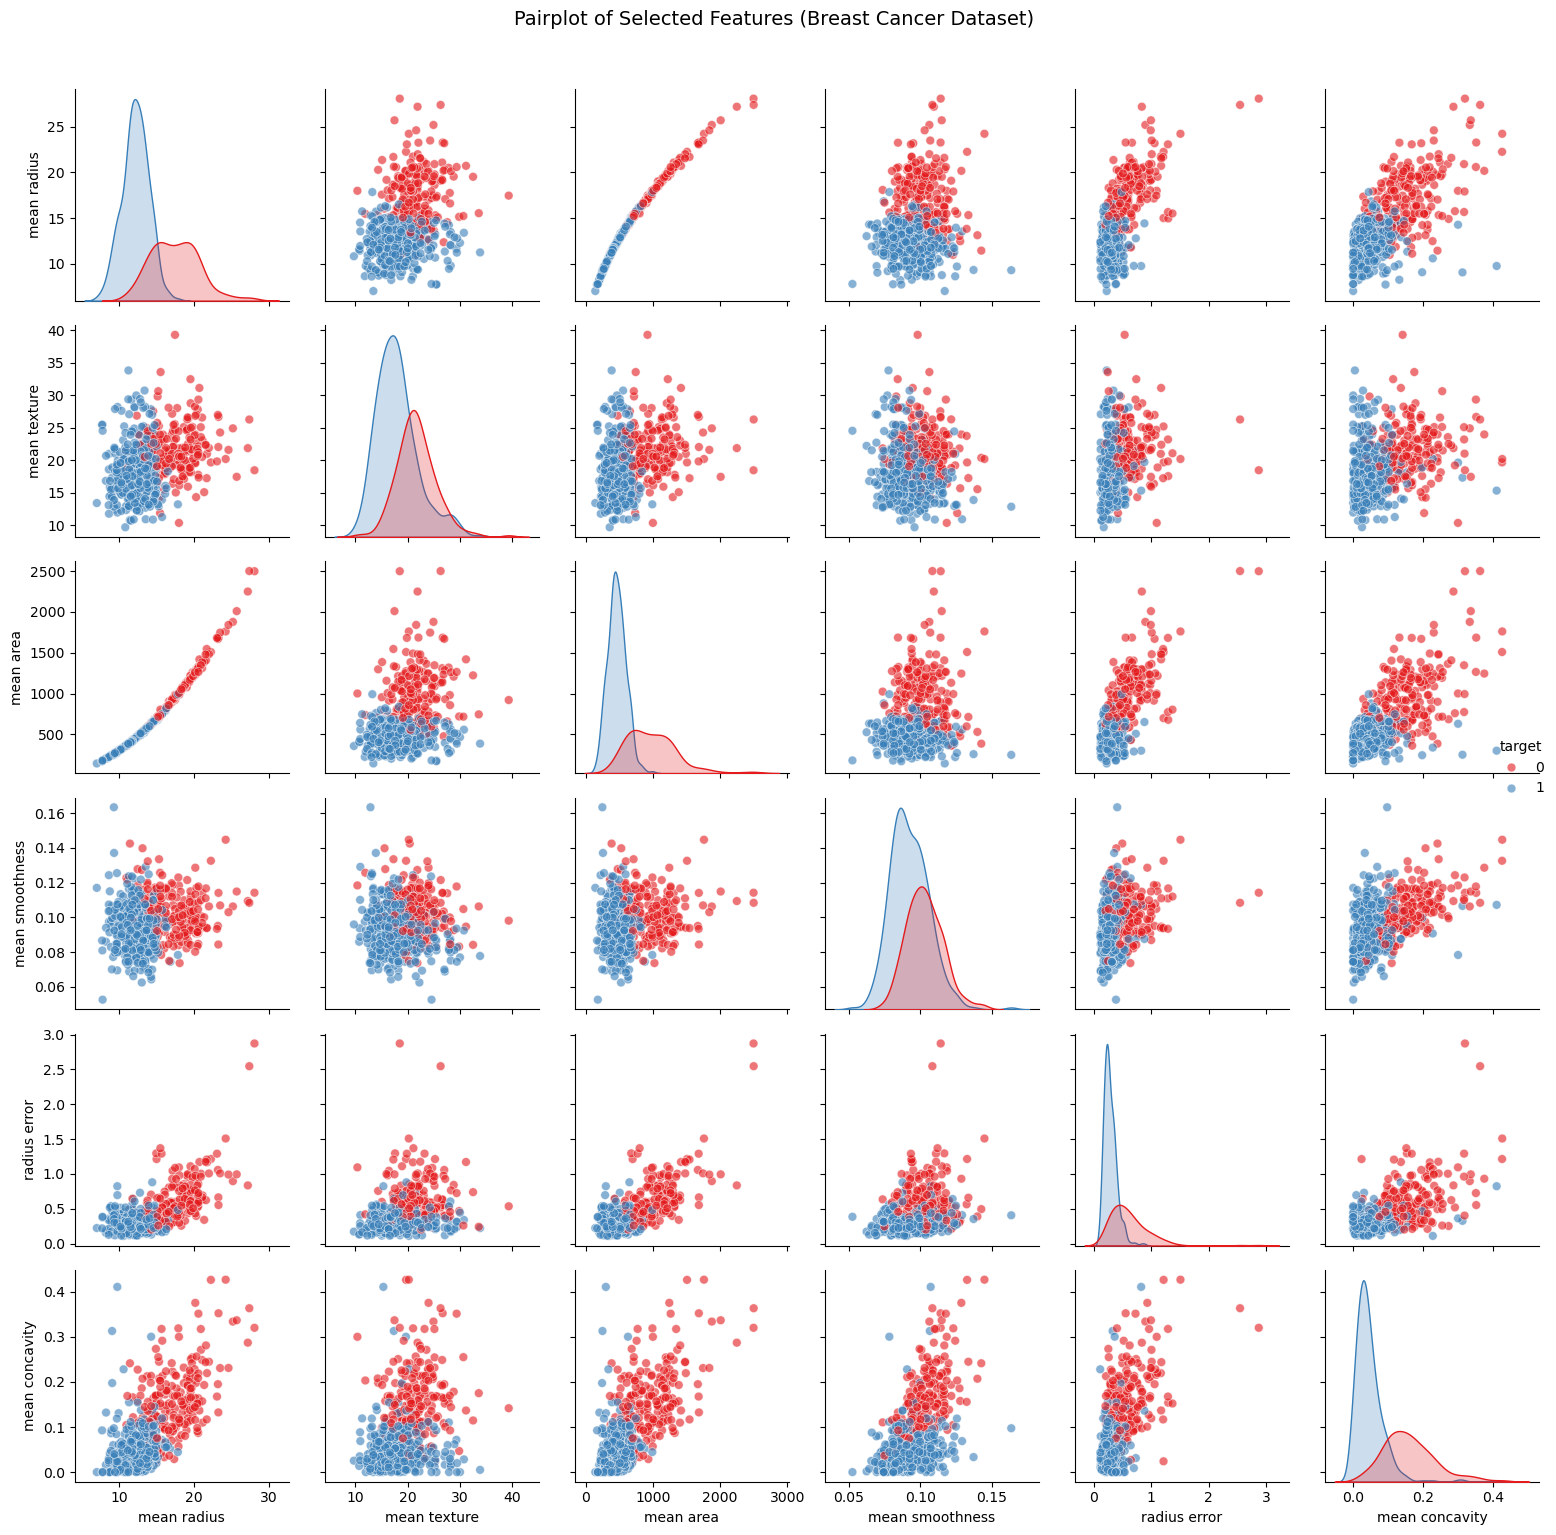

In [3]:
# Visualize feature relationships using pairplot
# Use a subset of features to keep the plot readable
subset_features = [
    'mean radius', 'mean texture', 'mean area', 'mean smoothness',
    'radius error', 'mean concavity'
]
plot_df = df[subset_features + ['target']]

plt.figure(figsize=(10, 10))
sns.pairplot(plot_df, hue='target', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
plt.suptitle('Pairplot of Selected Features (Breast Cancer Dataset)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape:  X={X_test.shape}, y={y_test.shape}")

Training set shape: X=(398, 30), y=(398,)
Testing set shape:  X=(171, 30), y=(171,)


In [5]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"X_test_scaled range:  [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")

Scaling complete.
X_train_scaled range: [-2.66, 10.89]
X_test_scaled range:  [-3.24, 14.71]


In [6]:
# (1) Logistic Regression
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# (2) Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy:       {dt_acc:.4f}")

Logistic Regression Accuracy: 0.9883
Decision Tree Accuracy:       0.9181




**From task 4 and 5, by comparing the baseline models & ensemble models, briefly discuss what have you found?**

Baseline models like Logistic Regression provide a simple linear decision boundary and serve as a good reference point. Decision Trees can capture non-linear patterns but are prone to overfitting. Ensemble models (Bagging, Random Forest, AdaBoost, Gradient Boosting) generally improve upon baseline performance by combining multiple weak learners. Random Forest and Gradient Boosting tend to achieve the highest accuracy because they reduce variance (through averaging) and bias (through sequential boosting), respectively. AdaBoost focuses on correcting misclassified samples iteratively. Overall, ensemble methods outperform or match the best baseline while being more robust to overfitting.

## 5. Ensemble Models (15 pts)

In [7]:
# (1) Bagging Classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
)
bagging.fit(X_train_scaled, y_train)
bagging_pred = bagging.predict(X_test_scaled)
bagging_acc = accuracy_score(y_test, bagging_pred)
print(f"Bagging Accuracy:              {bagging_acc:.4f}")

# (2) Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=False)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy:        {rf_acc:.4f}")

# (3) AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42,
)
ada.fit(X_train_scaled, y_train)
ada_pred = ada.predict(X_test_scaled)
ada_acc = accuracy_score(y_test, ada_pred)
print(f"AdaBoost Accuracy:             {ada_acc:.4f}")

# (4) Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)
gb_acc = accuracy_score(y_test, gb_pred)
print(f"Gradient Boosting Accuracy:    {gb_acc:.4f}")

# Summary comparison
print("\n--- Accuracy Summary ---")
results = {
    'Logistic Regression': lr_acc,
    'Decision Tree': dt_acc,
    'Bagging': bagging_acc,
    'Random Forest': rf_acc,
    'AdaBoost': ada_acc,
    'Gradient Boosting': gb_acc,
}
for name, acc in results.items():
    print(f"  {name:.<30s} {acc:.4f}")

Bagging Accuracy:              0.9474
Random Forest Accuracy:        0.9357
AdaBoost Accuracy:             0.9532
Gradient Boosting Accuracy:    0.9474

--- Accuracy Summary ---
  Logistic Regression........... 0.9883
  Decision Tree................. 0.9181
  Bagging....................... 0.9474
  Random Forest................. 0.9357
  AdaBoost...................... 0.9532
  Gradient Boosting............. 0.9474


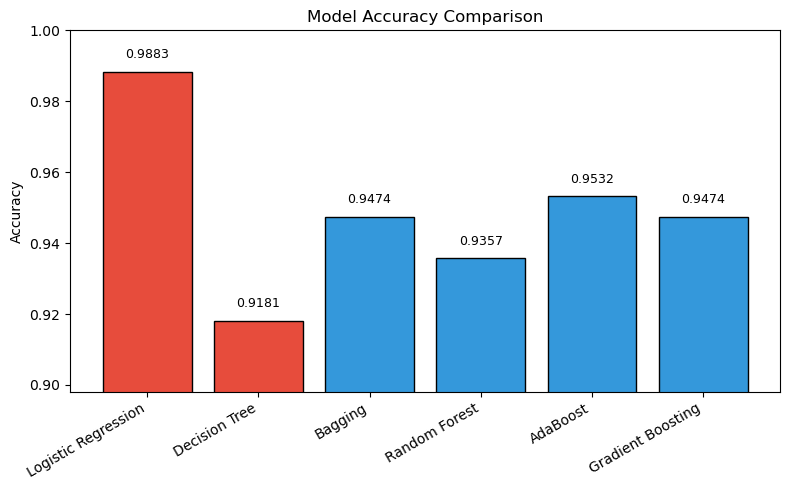

In [8]:
# Bar chart comparison of all models
fig, ax = plt.subplots(figsize=(8, 5))
models = list(results.keys())
accs = list(results.values())
colors = ['#e74c3c' if m in ['Logistic Regression', 'Decision Tree'] else '#3498db' for m in models]
bars = ax.bar(models, accs, color=colors, edgecolor='black')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(min(accs) - 0.02, 1.0)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Voting Classifier (hard voting) with 3 models
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=10000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('ada', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
            n_estimators=100, random_state=42)),
    ],
    voting='hard',
)
voting_clf.fit(X_train_scaled, y_train)
voting_pred = voting_clf.predict(X_test_scaled)
voting_acc = accuracy_score(y_test, voting_pred)
print(f"Voting Classifier Accuracy (hard): {voting_acc:.4f}")

Voting Classifier Accuracy (hard): 0.9649


In [10]:
# Stacking Classifier with 2 base models + Logistic Regression as final estimator
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)),
    ],
    final_estimator=LogisticRegression(max_iter=10000, random_state=42),
    cv=5,
)
stacking_clf.fit(X_train_scaled, y_train)
stacking_pred = stacking_clf.predict(X_test_scaled)
stacking_acc = accuracy_score(y_test, stacking_pred)
print(f"Stacking Classifier Accuracy:    {stacking_acc:.4f}")

# Summary
print(f"\n--- Meta-Ensemble Accuracy ---")
print(f"  Voting Classifier:  {voting_acc:.4f}")
print(f"  Stacking Classifier:{stacking_acc:.4f}")

Stacking Classifier Accuracy:    0.9474

--- Meta-Ensemble Accuracy ---
  Voting Classifier:  0.9649
  Stacking Classifier:0.9474




**What is the difference between the voting and stacking classifiers?**



Voting Classifier combines predictions from multiple base models using either hard voting (majority vote of predicted classes) or soft voting (averaging predicted probabilities). It is simple and does not require a meta-model to learn how to combine predictions.

Stacking Classifier (stacked generalization) uses a two-level approach: base models make predictions, and a meta-learner (final estimator) is trained on cross-validated predictions from the base models to learn the optimal way to combine them. Stacking can capture complex relationships between base model predictions but is more computationally expensive and risks overfitting the meta-learner if not properly regularized.

In [11]:
# Random Forest with OOB score enabled
rf_oob = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
)
rf_oob.fit(X_train_scaled, y_train)
print(f"OOB Score: {rf_oob.oob_score_:.4f}")
rf_oob_pred = rf_oob.predict(X_test_scaled)
rf_oob_test_acc = accuracy_score(y_test, rf_oob_pred)
print(f"Test Accuracy: {rf_oob_test_acc:.4f}")

OOB Score: 0.9573
Test Accuracy: 0.9357




**What is OOB?**



Out-of-Bag (OOB) score is an internal validation method for Random Forest. Each tree is trained on a bootstrap sample (random sampling with replacement), meaning about 1/3 of the training samples are not included in a given bootstrap sample — these are the "out-of-bag" samples for that tree. OOB prediction uses only the trees that did not see a particular sample during training to predict its label. The OOB score is the accuracy on all samples using only their out-of-bag estimators. It provides an unbiased estimate of generalization accuracy without needing a separate validation set.

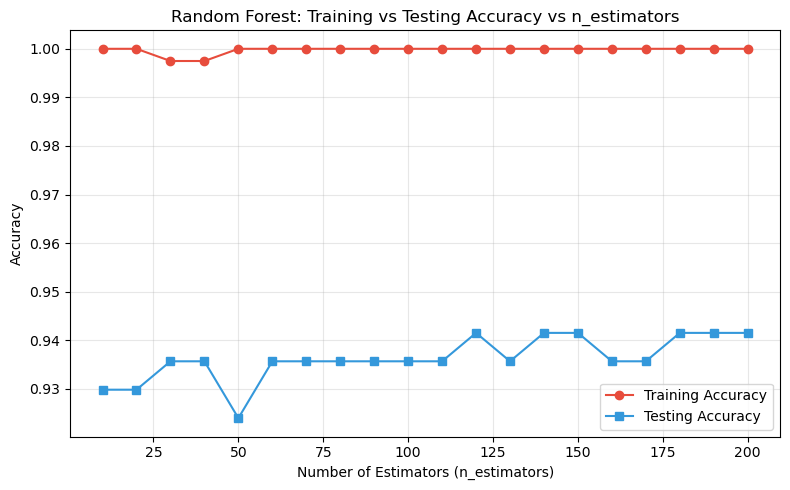

n_estimator | Train Acc | Test Acc
   10     |  1.0000  |  0.9298
   20     |  1.0000  |  0.9298
   30     |  0.9975  |  0.9357
   40     |  0.9975  |  0.9357
   50     |  1.0000  |  0.9240
   60     |  1.0000  |  0.9357
   70     |  1.0000  |  0.9357
   80     |  1.0000  |  0.9357
   90     |  1.0000  |  0.9357
  100     |  1.0000  |  0.9357
  110     |  1.0000  |  0.9357
  120     |  1.0000  |  0.9415
  130     |  1.0000  |  0.9357
  140     |  1.0000  |  0.9415
  150     |  1.0000  |  0.9415
  160     |  1.0000  |  0.9357
  170     |  1.0000  |  0.9357
  180     |  1.0000  |  0.9415
  190     |  1.0000  |  0.9415
  200     |  1.0000  |  0.9415


In [12]:
# Evaluate Random Forest with different n_estimators values
n_values = list(range(10, 201, 10))
train_scores = []
test_scores = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test_scaled)))

# Plot the curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_values, train_scores, 'o-', label='Training Accuracy', color='#e74c3c')
ax.plot(n_values, test_scores, 's-', label='Testing Accuracy', color='#3498db')
ax.set_xlabel('Number of Estimators (n_estimators)')
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest: Training vs Testing Accuracy vs n_estimators')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("n_estimator | Train Acc | Test Acc")
for n, tr, te in zip(n_values, train_scores, test_scores):
    print(f"  {n:3d}     |  {tr:.4f}  |  {te:.4f}")



**(1) What have you found from the curve plot?**


The curve shows that as n_estimators increases, both training and testing accuracy remain relatively stable after a certain point. Initially, with few trees (n=10), the model may underfit (higher bias). As more trees are added, the variance decreases due to averaging, and the model generalizes better. Eventually, adding more trees yields diminishing returns — accuracy plateaus. This demonstrates that Random Forest is relatively robust to the choice of n_estimators; a sufficiently large number of trees reduces variance without increasing overfitting.

**(2) What is Bias-Variance trade-off?**


The Bias-Variance trade-off describes the balance between two sources of error in predictive models:
- **Bias**: Error from overly simplistic assumptions in the learning algorithm. High-bias models underfit — they miss relevant patterns (e.g., linear models on non-linear data).
- **Variance**: Error from sensitivity to small fluctuations in the training data. High-variance models overfit — they capture noise as if it were signal (e.g., deep decision trees).

Ensemble methods address this trade-off: Bagging (e.g., Random Forest) reduces variance by averaging multiple models; Boosting (e.g., AdaBoost, Gradient Boosting) reduces bias by sequentially correcting errors. Random Forest achieves low variance through tree averaging while maintaining low bias through diverse, decorrelated trees.

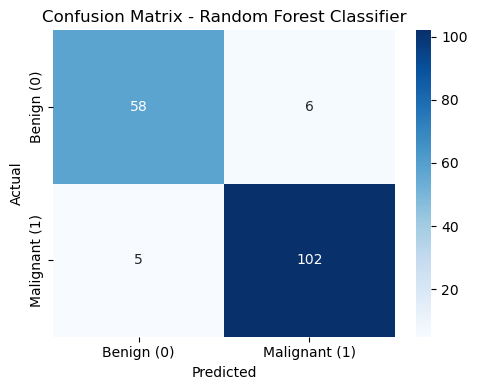

Confusion Matrix:
[[ 58   6]
 [  5 102]]

True Negatives:  58  | False Positives: 6
False Negatives: 5  | True Positives:  102


In [13]:
# Confusion Matrix from Random Forest predictions
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Random Forest Classifier')
plt.tight_layout()
plt.show()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives:  {cm[0,0]}  | False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}  | True Positives:  {cm[1,1]}")

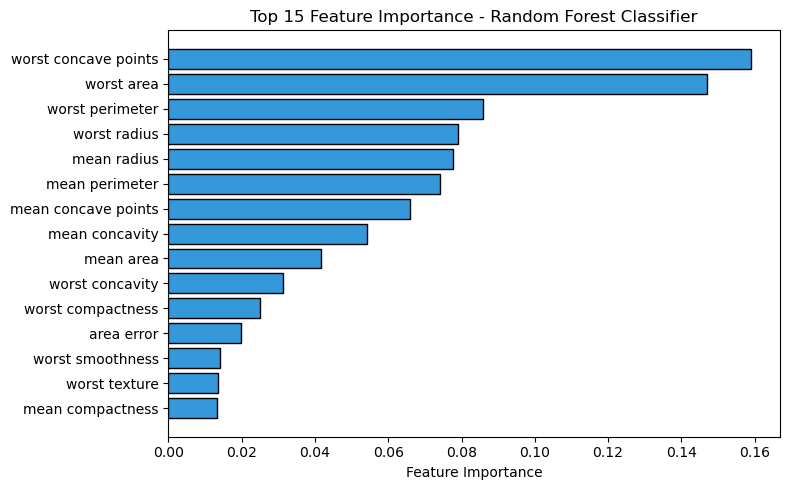

Top 15 Feature Importances:
   1. worst concave points............... 0.1590
   2. worst area......................... 0.1470
   3. worst perimeter.................... 0.0858
   4. worst radius....................... 0.0790
   5. mean radius........................ 0.0777
   6. mean perimeter..................... 0.0742
   7. mean concave points................ 0.0659
   8. mean concavity..................... 0.0543
   9. mean area.......................... 0.0417
  10. worst concavity.................... 0.0314
  11. worst compactness.................. 0.0250
  12. area error......................... 0.0199
  13. worst smoothness................... 0.0142
  14. worst texture...................... 0.0136
  15. mean compactness................... 0.0132


In [14]:
# Feature importance from Random Forest
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot top 15 most important features
top_n = 15
top_indices = indices[:top_n]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(top_n), importances[top_indices], color='#3498db', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in top_indices])
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {top_n} Feature Importance - Random Forest Classifier')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 15 Feature Importances:")
for rank, i in enumerate(top_indices):
    print(f"  {rank+1:2d}. {feature_names[i]:.<35s} {importances[i]:.4f}")

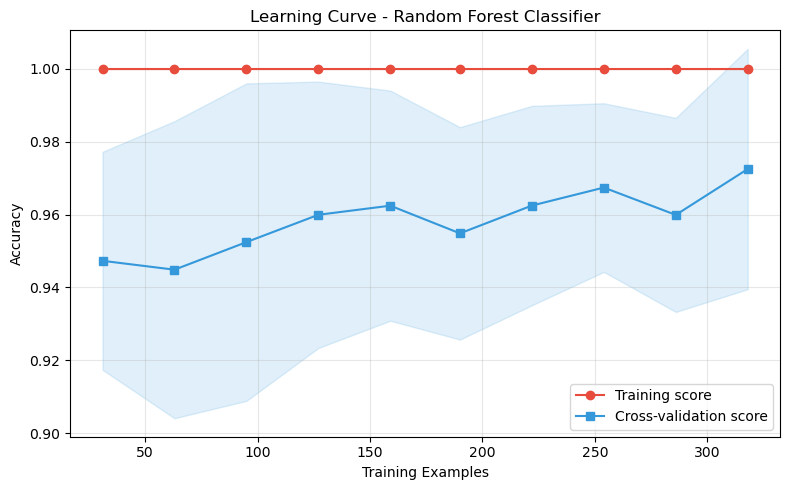

Learning Curve Data:
  Train size  |  Train Score (± std)  |  CV Score (± std)
    31  |  1.0000 ± 0.0000  |  0.9473 ± 0.0299
    63  |  1.0000 ± 0.0000  |  0.9449 ± 0.0408
    95  |  1.0000 ± 0.0000  |  0.9524 ± 0.0436
   127  |  1.0000 ± 0.0000  |  0.9599 ± 0.0365
   159  |  1.0000 ± 0.0000  |  0.9624 ± 0.0316
   190  |  1.0000 ± 0.0000  |  0.9548 ± 0.0291
   222  |  1.0000 ± 0.0000  |  0.9625 ± 0.0274
   254  |  1.0000 ± 0.0000  |  0.9674 ± 0.0231
   286  |  1.0000 ± 0.0000  |  0.9599 ± 0.0266
   318  |  1.0000 ± 0.0000  |  0.9725 ± 0.0330


In [15]:
# Learning curve for Random Forest
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_scaled, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
    n_jobs=-1,
)

train_mean = np.mean(train_scores_lc, axis=1)
train_std = np.std(train_scores_lc, axis=1)
val_mean = np.mean(val_scores_lc, axis=1)
val_std = np.std(val_scores_lc, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', label='Training score', color='#e74c3c')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, val_mean, 's-', label='Cross-validation score', color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3498db')
ax.set_xlabel('Training Examples')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve - Random Forest Classifier')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Learning Curve Data:")
print(f"  Train size  |  Train Score (± std)  |  CV Score (± std)")
for i in range(len(train_sizes)):
    print(f"  {int(train_sizes[i]):4d}  |  {train_mean[i]:.4f} ± {train_std[i]:.4f}  |  {val_mean[i]:.4f} ± {val_std[i]:.4f}")